# HackUDC 2026 — Inditex · Análisis Exploratorio de Datos
## + Descarga optimizada del catálogo de imágenes

**Dataset:** Bundle-to-Product Matching  
**Objetivo:** Entender la estructura de los datos antes de modelar, e identificar patrones que guíen las decisiones de diseño del sistema de retrieval.

---
## 0 · Setup

In [1]:
import warnings, os, time, hashlib, sys
from pathlib import Path
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import requests
from PIL import Image
from tqdm.auto import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Estilo global ────────────────────────────────────────────────
PALETTE  = ['#1a1a2e', '#16213e', '#0f3460', '#e94560',
             '#533483', '#2b9348', '#f4a261', '#457b9d']
ACCENT   = '#e94560'
DARK_BG  = '#0d1117'
MID_BG   = '#161b22'
TEXT_CLR = '#e6edf3'

plt.rcParams.update({
    'figure.facecolor'  : DARK_BG,
    'axes.facecolor'    : MID_BG,
    'axes.edgecolor'    : '#30363d',
    'axes.labelcolor'   : TEXT_CLR,
    'axes.titlecolor'   : TEXT_CLR,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.grid'         : True,
    'grid.color'        : '#21262d',
    'grid.linewidth'    : 0.7,
    'xtick.color'       : '#8b949e',
    'ytick.color'       : '#8b949e',
    'text.color'        : TEXT_CLR,
    'legend.facecolor'  : '#21262d',
    'legend.edgecolor'  : '#30363d',
    'legend.fontsize'   : 9,
    'font.family'       : 'monospace',
    'figure.dpi'        : 110,
    'savefig.dpi'       : 130,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : DARK_BG,
})

CMAP_ACCENT = LinearSegmentedColormap.from_list('acc', [MID_BG, ACCENT])
CMAP_BLUE   = LinearSegmentedColormap.from_list('blu', [MID_BG, '#457b9d'])

# ── Paths ────────────────────────────────────────────────────────
DATA_DIR  = Path('data')
OUT_DIR   = Path('output/eda'); OUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR   = Path('cache/images'); IMG_DIR.mkdir(parents=True, exist_ok=True)
(IMG_DIR / 'bundles').mkdir(exist_ok=True)
(IMG_DIR / 'products').mkdir(exist_ok=True)

def savefig(name):
    plt.savefig(OUT_DIR / f'{name}.png', bbox_inches='tight')
    plt.show()

print('Setup OK ✓')

/home/xoel/.local/share/virtualenvs/HackUDC2026-gszqN3--/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup OK ✓


---
## 1 · Carga y saneamiento

In [ ]:
bundles  = pd.read_csv(DATA_DIR / 'bundles_dataset.csv')
products = pd.read_csv(DATA_DIR / 'product_dataset.csv')
train    = pd.read_csv(DATA_DIR / 'bundles_product_match_train.csv')
test     = pd.read_csv(DATA_DIR / 'bundles_product_match_test.csv')

# Test tiene product_asset_id todo NaN (es la columna a predecir)
test = test[['bundle_asset_id']].copy()

# Enriquecimiento base
train_rich = (
    train
    .merge(bundles[['bundle_asset_id','bundle_id_section']], on='bundle_asset_id')
    .merge(products[['product_asset_id','product_description']],  on='product_asset_id')
)

# Lookups rápidos
b_url  = bundles.set_index('bundle_asset_id')['bundle_image_url'].to_dict()
b_sect = bundles.set_index('bundle_asset_id')['bundle_id_section'].to_dict()
p_url  = products.set_index('product_asset_id')['product_image_url'].to_dict()
p_cat  = products.set_index('product_asset_id')['product_description'].to_dict()

SECTION_NAMES = {1: 'Woman', 2: 'Man', 3: 'Kids'}  # inferido del análisis de categorías

# ── Resumen de integridad ────────────────────────────────────────
print('╔═══════════════════════════════════════════════════════╗')
print('║            RESUMEN DE INTEGRIDAD DEL DATASET          ║')
print('╠═══════════════════════════════════════════════════════╣')
for name, df in [('bundles', bundles), ('products', products),
                  ('train', train), ('test', test)]:
    nulls = df.isnull().sum().sum()
    dups  = df.duplicated().sum()
    print(f'║  {name:<10} {len(df):>7,} filas  |  nulls={nulls}  dups={dups}  ║')
print('╠═══════════════════════════════════════════════════════╣')
overlap = len(set(test.bundle_asset_id) & set(train.bundle_asset_id))
print(f'║  Overlap train∩test bundles          : {overlap}              ║')
orphan_train = len(set(train.bundle_asset_id) - set(bundles.bundle_asset_id))
orphan_prod  = len(set(train.product_asset_id) - set(products.product_asset_id))
print(f'║  Bundles en train sin metadata       : {orphan_train}              ║')
print(f'║  Productos en train sin metadata     : {orphan_prod}              ║')
print(f'║  Catálogo visto en train             : {len(set(train.product_asset_id)):>4,} / {len(products):,}  ║')
print(f'║  Catálogo NO visto (cold-start)      : {len(set(products.product_asset_id)-set(train.product_asset_id)):>5,} / {len(products):,}  ║')
print('╚═══════════════════════════════════════════════════════╝')

╔═══════════════════════════════════════════════════════╗
║            RESUMEN DE INTEGRIDAD DEL DATASET         ║
╠═══════════════════════════════════════════════════════╣
║  bundles      2,331 filas  |  nulls=0  dups=0  ║
║  products    27,688 filas  |  nulls=0  dups=0  ║
║  train        6,493 filas  |  nulls=0  dups=0  ║
║  test           455 filas  |  nulls=0  dups=0  ║
╠═══════════════════════════════════════════════════════╣
║  Overlap train∩test bundles          : 0              ║
║  Bundles en train sin metadata        : 0              ║
║  Productos en train sin metadata      : 0              ║
║  Catálogo visto en train              : 4,012 / 27,688  ║
║  Catálogo NO visto (cold-start)       : 23,676 / 27,688  ║
╚═══════════════════════════════════════════════════════╝


In [20]:
# ── Estadísticas descriptivas clave ────────────────────────────
ppb = train.groupby('bundle_asset_id').size()   # productos por bundle
bpt = train.groupby('product_asset_id').size()  # bundles por producto

seen_pids   = set(train.product_asset_id)
unseen_pids = set(products.product_asset_id) - seen_pids
overlap     = set(test.bundle_asset_id) & set(train.bundle_asset_id)

print('══════════════════════════════════════════════════════════════')
print('  ESTADÍSTICAS DESCRIPTIVAS GLOBALES')
print('══════════════════════════════════════════════════════════════')
print(f'  Bundles totales en catálogo      : {len(bundles):>7,}')
print(f'    · En train                     : {train.bundle_asset_id.nunique():>7,}  ({train.bundle_asset_id.nunique()/len(bundles)*100:.1f}%)')
print(f'    · En test                      : {len(test):>7,}  ({len(test)/len(bundles)*100:.1f}%)')
print(f'    · Overlap train ∩ test         : {len(overlap):>7,}  ← data leakage check')
print()
print(f'  Productos totales en catálogo    : {len(products):>7,}')
print(f'    · Vistos en train (≥1 par)     : {len(seen_pids):>7,}  ({len(seen_pids)/len(products)*100:.1f}%)')
print(f'    · NO vistos (cold-start)       : {len(unseen_pids):>7,}  ({len(unseen_pids)/len(products)*100:.1f}%)')
print(f'    · Categorías únicas            : {products.product_description.nunique():>7,}')
print(f'    · Media productos/categoría    : {len(products)/products.product_description.nunique():>7.1f}')
print()
print(f'  Pares de entrenamiento           : {len(train):>7,}')
print(f'  Secciones comerciales            : {bundles.bundle_id_section.nunique():>7,}  (1=Woman, 2=Man, 3=Kids)')
print()
print('  Productos por bundle (train):')
print(f'    · Media   : {ppb.mean():.2f}')
print(f'    · Mediana : {ppb.median():.0f}')
print(f'    · Std     : {ppb.std():.2f}')
print(f'    · Mínimo  : {ppb.min()}')
print(f'    · Máximo  : {ppb.max()}')
print(f'    · P25     : {ppb.quantile(.25):.0f}')
print(f'    · P75     : {ppb.quantile(.75):.0f}')
print()
print('  Bundles por producto (reutilización):')
print(f'    · Media   : {bpt.mean():.2f}')
print(f'    · Mediana : {bpt.median():.0f}')
print(f'    · Std     : {bpt.std():.2f}')
print(f'    · Máximo  : {bpt.max()}  (producto más reutilizado)')
print(f'    · Usados 1 sola vez: {(bpt==1).sum():,}  ({(bpt==1).sum()/len(bpt)*100:.1f}%)')
print(f'    · Usados 5+ veces  : {(bpt>=5).sum():,}  ({(bpt>=5).sum()/len(bpt)*100:.1f}%)')
print('══════════════════════════════════════════════════════════════')

══════════════════════════════════════════════════════════════
  ESTADÍSTICAS DESCRIPTIVAS GLOBALES
══════════════════════════════════════════════════════════════
  Bundles totales en catálogo      :   2,331
    · En train                     :   1,876  (80.5%)
    · En test                      :     455  (19.5%)
    · Overlap train ∩ test         :       0  ← data leakage check

  Productos totales en catálogo    :  27,688
    · Vistos en train (≥1 par)     :   4,012  (14.5%)
    · NO vistos (cold-start)       :  23,676  (85.5%)
    · Categorías únicas            :     127
    · Media productos/categoría    :   218.0

  Pares de entrenamiento           :   6,493
  Secciones comerciales            :       3  (1=Woman, 2=Man, 3=Kids)

  Productos por bundle (train):
    · Media   : 3.46
    · Mediana : 3
    · Std     : 1.76
    · Mínimo  : 1
    · Máximo  : 11
    · P25     : 2
    · P75     : 4

  Bundles por producto (reutilización):
    · Media   : 1.62
    · Mediana : 1
    · Std 

---
## 2 · Distribuciones globales

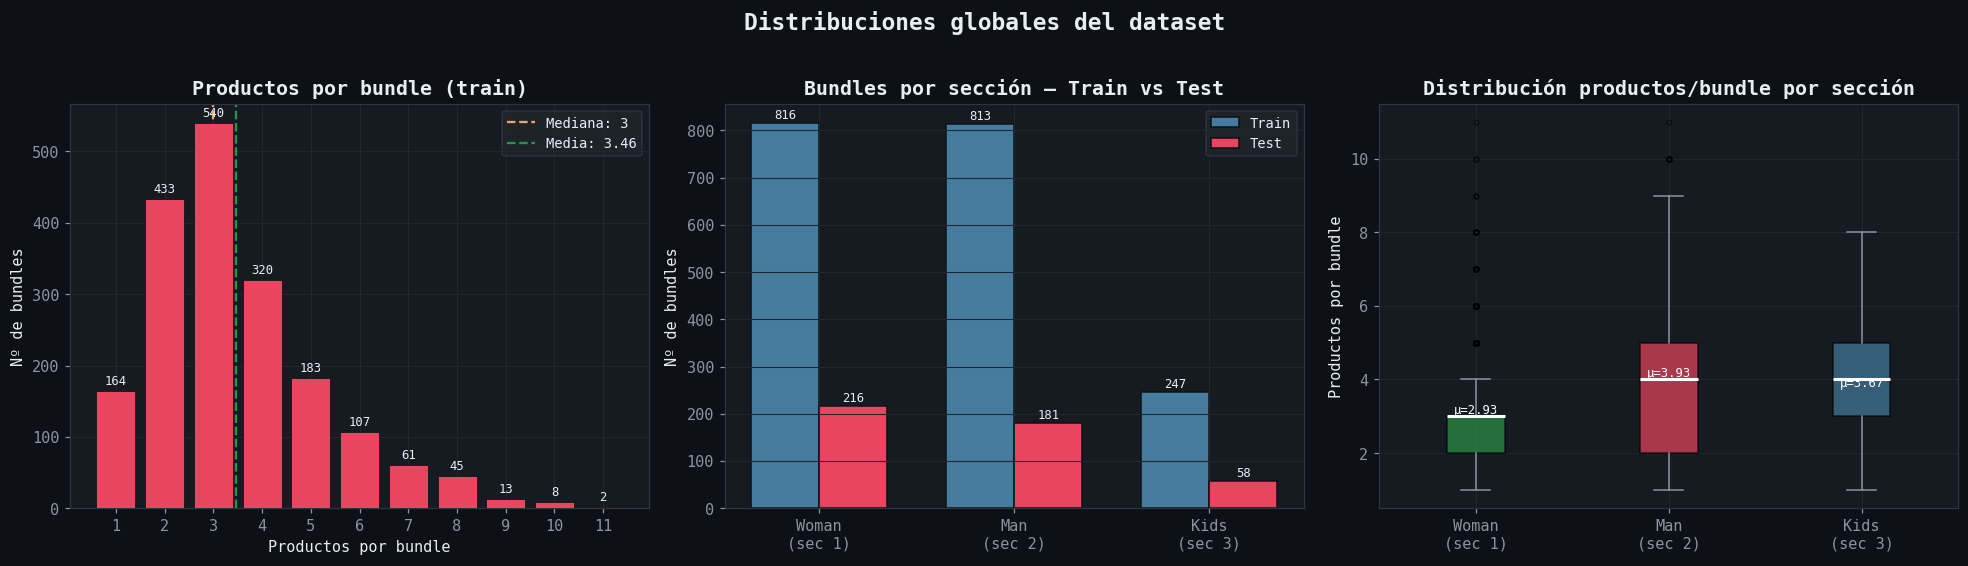

In [3]:
ppb   = train.groupby('bundle_asset_id').size()           # productos por bundle
ppb_s = {s: train[train.bundle_asset_id.isin(
             bundles[bundles.bundle_id_section==s].bundle_asset_id)]
           .groupby('bundle_asset_id').size()
         for s in [1,2,3]}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribuciones globales del dataset', fontsize=15, fontweight='bold', y=1.02)

# ── 2.1 Productos por bundle ────────────────────────────────────
ax = axes[0]
vc = ppb.value_counts().sort_index()
bars = ax.bar(vc.index, vc.values, color=ACCENT, edgecolor=DARK_BG, linewidth=0.5, zorder=3)
# Mediana y media
ax.axvline(ppb.median(), color='#f4a261', linestyle='--', linewidth=1.5,
           label=f'Mediana: {ppb.median():.0f}')
ax.axvline(ppb.mean(),   color='#2b9348', linestyle='--', linewidth=1.5,
           label=f'Media: {ppb.mean():.2f}')
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(v), ha='center', va='bottom', fontsize=8, color=TEXT_CLR)
ax.set_xlabel('Productos por bundle'); ax.set_ylabel('Nº de bundles')
ax.set_title('Productos por bundle (train)')
ax.legend(); ax.set_xticks(vc.index)

# ── 2.2 Distribución por sección ───────────────────────────────
ax = axes[1]
sect_train = bundles[bundles.bundle_asset_id.isin(train.bundle_asset_id)]['bundle_id_section'].value_counts().sort_index()
sect_test  = bundles[bundles.bundle_asset_id.isin(test.bundle_asset_id)]['bundle_id_section'].value_counts().sort_index()
x = np.arange(len(sect_train))
w = 0.35
b1 = ax.bar(x-w/2, sect_train.values, w, label='Train', color='#457b9d', edgecolor=DARK_BG)
b2 = ax.bar(x+w/2, sect_test.values,  w, label='Test',  color=ACCENT,    edgecolor=DARK_BG)
ax.set_xticks(x)
ax.set_xticklabels([f'{SECTION_NAMES.get(s,s)}\n(sec {s})' for s in sect_train.index])
ax.set_title('Bundles por sección — Train vs Test')
ax.set_ylabel('Nº de bundles')
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+3, str(h),
            ha='center', va='bottom', fontsize=8, color=TEXT_CLR)
ax.legend()

# ── 2.3 Productos por bundle por sección (boxplot) ───────────────
ax = axes[2]
colors_sect = [PALETTE[5], PALETTE[3], PALETTE[7]]
data_bp = [ppb_s[s].values for s in [1,2,3]]
bp = ax.boxplot(data_bp, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#8b949e'),
                capprops=dict(color='#8b949e'),
                flierprops=dict(marker='o', color=ACCENT, markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], colors_sect):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticklabels([f'{SECTION_NAMES[s]}\n(sec {s})' for s in [1,2,3]])
ax.set_title('Distribución productos/bundle por sección')
ax.set_ylabel('Productos por bundle')
# Añadir medias
for i, s in enumerate([1,2,3], 1):
    ax.text(i, ppb_s[s].mean()+0.15, f'μ={ppb_s[s].mean():.2f}',
            ha='center', fontsize=8, color='white')

plt.tight_layout()
savefig('01_distribuciones_globales')

---
## 3 · Catálogo de productos: tamaño, cobertura y categorías

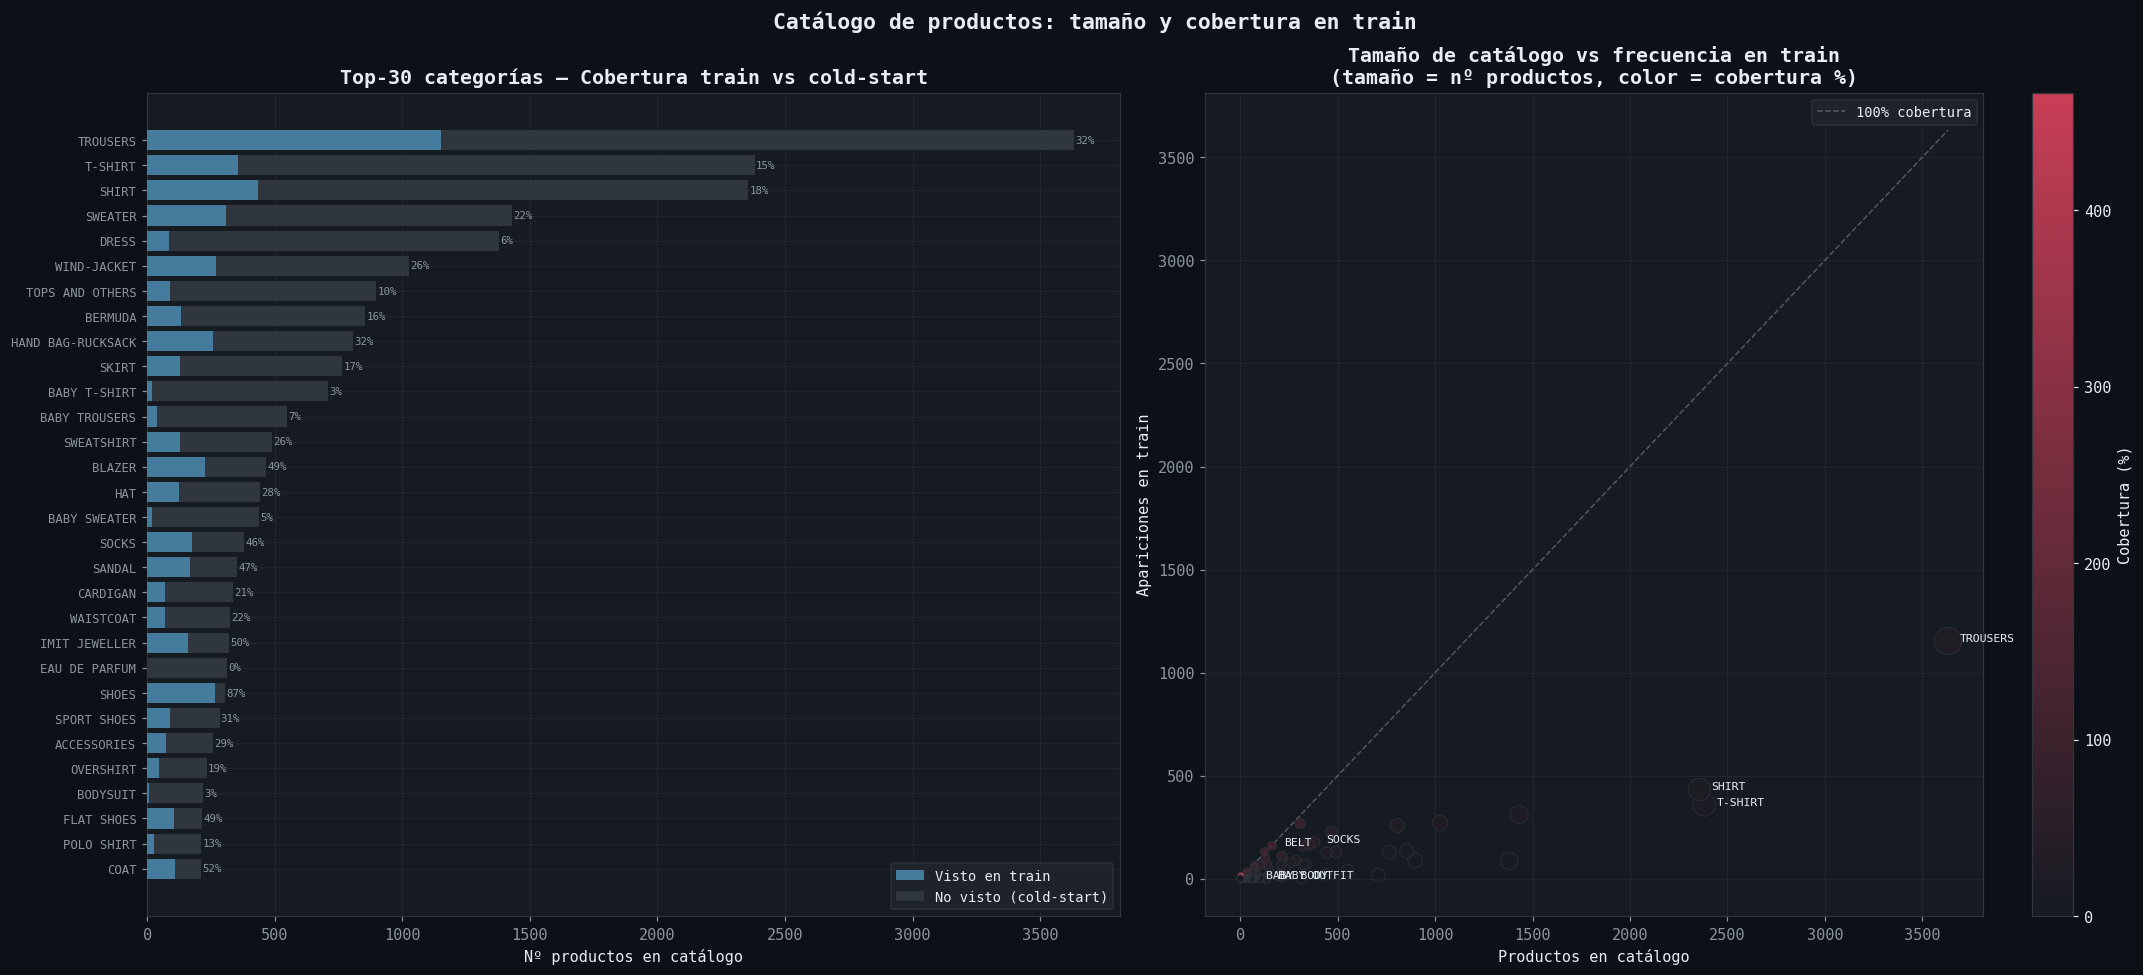


  Categorías con 0% cobertura en train: 39
  Categorías con >50% cobertura       : 21
  Categoría con mayor cold-start gap  : TROUSERS (2,479 productos)


In [ ]:
# Cobertura del catálogo en train por categoría
cat_catalog = products.product_description.value_counts()
cat_train   = train_rich.product_description.value_counts()
coverage_df = pd.DataFrame({
    'catalog'  : cat_catalog,
    'train'    : cat_train
}).fillna(0).astype({'catalog': int, 'train': int})
coverage_df['coverage_pct'] = coverage_df['train'] / coverage_df['catalog'] * 100
coverage_df['unseen']       = coverage_df['catalog'] - coverage_df['train']
coverage_df = coverage_df.sort_values('catalog', ascending=False)

# Top-30 categorías con cobertura
top30 = coverage_df.head(30)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Catálogo de productos: tamaño y cobertura en train', fontsize=14, fontweight='bold')

# ── 3.1 Stacked bar: visto vs no visto ─────────────────────────
ax = axes[0]
y  = np.arange(len(top30))
ax.barh(y, top30['train'],   color='#457b9d', label='Visto en train', zorder=3)
ax.barh(y, top30['unseen'],  left=top30['train'], color='#30363d',
        label='No visto (cold-start)', zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(top30.index, fontsize=8)
ax.set_xlabel('Nº productos en catálogo')
ax.set_title('Top-30 categorías — Cobertura train vs cold-start')
ax.legend(loc='lower right')
ax.invert_yaxis()
# Porcentaje de cobertura al final
for i, (_, row) in enumerate(top30.iterrows()):
    ax.text(row['catalog']+5, i, f"{row['coverage_pct']:.0f}%",
            va='center', fontsize=7, color='#8b949e')

# ── 3.2 Scatter: tamaño catálogo vs frecuencia en train ──────────
ax = axes[1]
sc = ax.scatter(
    coverage_df['catalog'],
    coverage_df['train'],
    c=coverage_df['coverage_pct'],
    cmap=CMAP_ACCENT,
    s=coverage_df['catalog'] / coverage_df['catalog'].max() * 300 + 20,
    alpha=0.85, edgecolors='#30363d', linewidths=0.5, zorder=3
)
# Línea de referencia (cobertura perfecta)
mx = max(coverage_df['catalog'].max(), coverage_df['train'].max())
ax.plot([0, mx], [0, mx], '--', color='#8b949e', linewidth=1, alpha=0.5, label='100% cobertura')
# Anotar categorías extremas
for cat in ['TROUSERS','T-SHIRT','SHIRT','BABY BODY','BABY OUTFIT','SOCKS','BELT']:
    if cat in coverage_df.index:
        r = coverage_df.loc[cat]
        ax.annotate(cat, (r['catalog'], r['train']),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=7.5, color=TEXT_CLR)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Cobertura (%)', color=TEXT_CLR)
cbar.ax.yaxis.set_tick_params(color=TEXT_CLR)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_CLR)
ax.set_xlabel('Productos en catálogo')
ax.set_ylabel('Apariciones en train')
ax.set_title('Tamaño de catálogo vs frecuencia en train\n(tamaño = nº productos, color = cobertura %)')
ax.legend(fontsize=9)

plt.tight_layout()
savefig('02_cobertura_catalogo')

print(f"\n  Categorías con 0% cobertura en train: "
      f"{(coverage_df['coverage_pct']==0).sum()}")
print(f"  Categorías con >50% cobertura       : "
      f"{(coverage_df['coverage_pct']>50).sum()}")
print(f"  Categoría con mayor cold-start gap  : "
      f"{coverage_df['unseen'].idxmax()} ({coverage_df['unseen'].max():,} productos)")

---
## 4 · Análisis por sección comercial

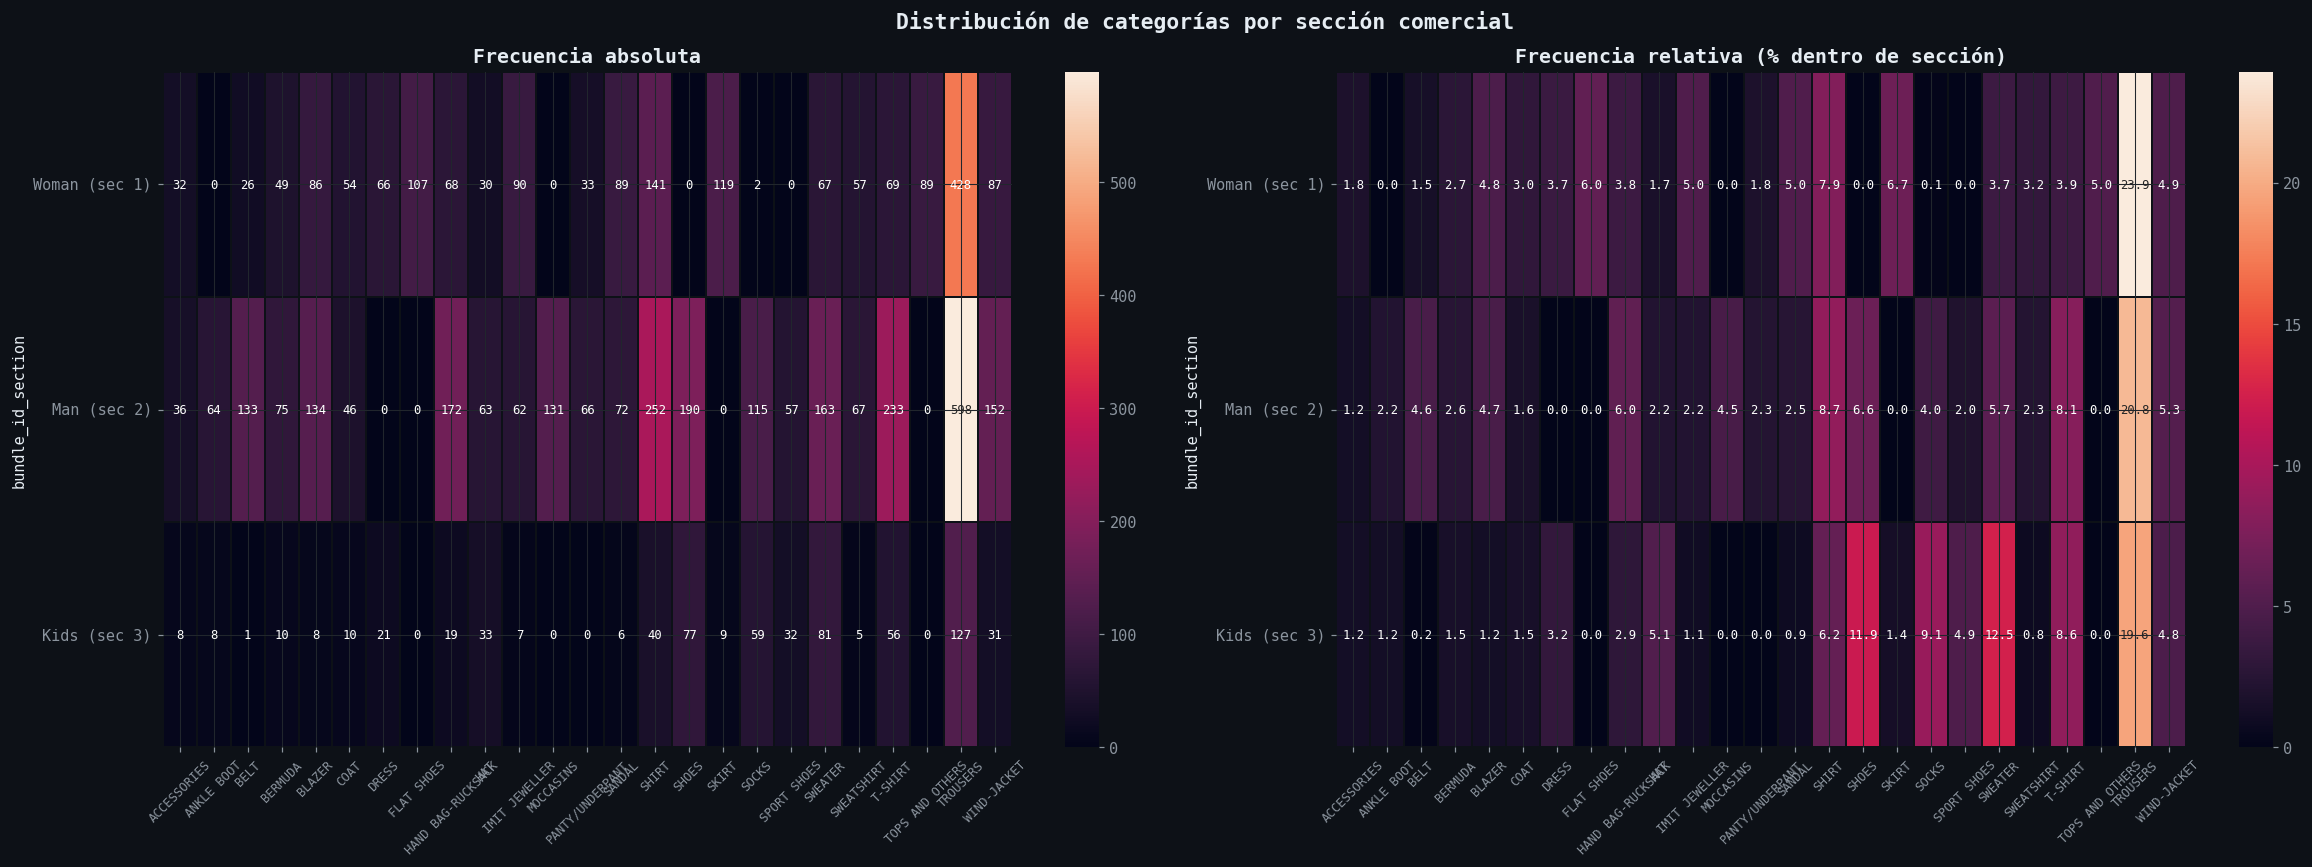

In [5]:
# ── Heatmap sección x categoría ─────────────────────────────────
top_cats_global = train_rich.product_description.value_counts().head(25).index

hm_data = (
    train_rich[train_rich.product_description.isin(top_cats_global)]
    .groupby(['bundle_id_section','product_description'])
    .size().unstack(fill_value=0)
)
# Normalizar por filas (frecuencia relativa dentro de cada sección)
hm_norm = hm_data.div(hm_data.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('Distribución de categorías por sección comercial', fontsize=14, fontweight='bold')

# Heatmap absoluto
sns.heatmap(hm_data, ax=axes[0], cmap='rocket', annot=True, fmt='d',
            annot_kws={'size': 8}, linewidths=0.3, linecolor='#0d1117',
            yticklabels=[f'{SECTION_NAMES.get(s,s)} (sec {s})' for s in hm_data.index])
axes[0].set_title('Frecuencia absoluta')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0)

# Heatmap normalizado (% dentro de sección)
sns.heatmap(hm_norm, ax=axes[1], cmap='rocket', annot=True, fmt='.1f',
            annot_kws={'size': 8}, linewidths=0.3, linecolor='#0d1117',
            yticklabels=[f'{SECTION_NAMES.get(s,s)} (sec {s})' for s in hm_norm.index])
axes[1].set_title('Frecuencia relativa (% dentro de sección)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0)

for ax in axes:
    ax.figure.axes[-1].yaxis.label.set_color(TEXT_CLR)

plt.tight_layout()
savefig('03_heatmap_seccion_categoria')

Categorías con >80% de apariciones en una sola sección: 56 / 88


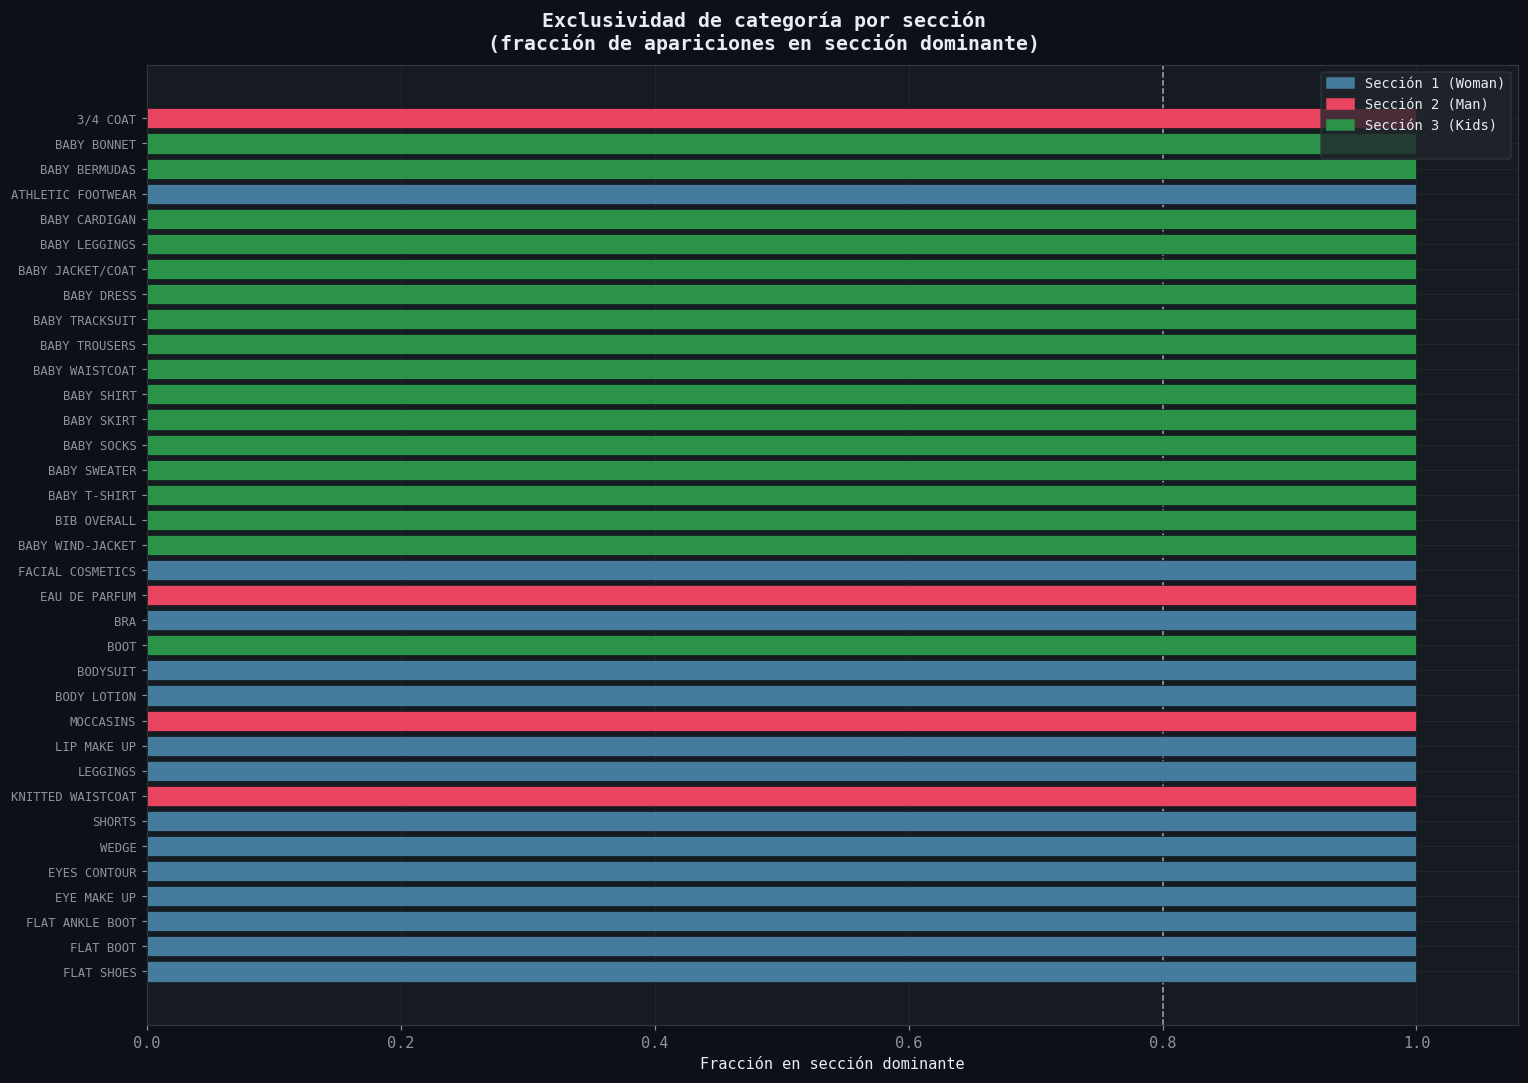


Categorías 100% exclusivas de una sección:
  3/4 COAT                       → Man (sec 2)
  BABY BONNET                    → Kids (sec 3)
  BABY BERMUDAS                  → Kids (sec 3)
  ATHLETIC FOOTWEAR              → Woman (sec 1)
  BABY CARDIGAN                  → Kids (sec 3)
  BABY LEGGINGS                  → Kids (sec 3)
  BABY JACKET/COAT               → Kids (sec 3)
  BABY DRESS                     → Kids (sec 3)
  BABY TRACKSUIT                 → Kids (sec 3)
  BABY TROUSERS                  → Kids (sec 3)
  BABY WAISTCOAT                 → Kids (sec 3)
  BABY SHIRT                     → Kids (sec 3)
  BABY SKIRT                     → Kids (sec 3)
  BABY SOCKS                     → Kids (sec 3)
  BABY SWEATER                   → Kids (sec 3)
  BABY T-SHIRT                   → Kids (sec 3)
  BIB OVERALL                    → Kids (sec 3)
  BABY WIND-JACKET               → Kids (sec 3)
  FACIAL COSMETICS               → Woman (sec 1)
  EAU DE PARFUM                  → Man (sec

In [6]:
# ── Exclusividad de categoría por sección ────────────────────────
# ¿Qué fracción de apariciones de cada categoría cae en cada sección?
cat_sect_share = (
    train_rich.groupby(['product_description','bundle_id_section'])
    .size().unstack(fill_value=0)
)
cat_sect_share = cat_sect_share.div(cat_sect_share.sum(axis=1), axis=0)
max_share      = cat_sect_share.max(axis=1).sort_values(ascending=False)
dominant_sect  = cat_sect_share.idxmax(axis=1)

# Categorías altamente exclusivas (>80% en una sola sección)
exclusive_cats = max_share[max_share > 0.8]
print(f"Categorías con >80% de apariciones en una sola sección: "
      f"{len(exclusive_cats)} / {len(max_share)}")

# Visualización
fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('Exclusividad de categoría por sección\n'
             '(fracción de apariciones en sección dominante)',
             fontsize=13, fontweight='bold')

top_exclusive = max_share.head(35)
colors_bars = []
for cat in top_exclusive.index:
    s = dominant_sect[cat]
    colors_bars.append({1: '#457b9d', 2: ACCENT, 3: '#2b9348'}.get(s, '#f4a261'))

bars = ax.barh(range(len(top_exclusive)), top_exclusive.values[::-1],
               color=colors_bars[::-1], edgecolor=DARK_BG, linewidth=0.4, zorder=3)
ax.set_yticks(range(len(top_exclusive)))
ax.set_yticklabels(top_exclusive.index[::-1], fontsize=8)
ax.set_xlabel('Fracción en sección dominante')
ax.axvline(0.8, color='white', linestyle='--', linewidth=1, alpha=0.6, label='Umbral 80%')
ax.set_xlim(0, 1.08)
# Leyenda de secciones
legend_patches = [
    mpatches.Patch(color='#457b9d', label=f'Sección 1 ({SECTION_NAMES[1]})'),
    mpatches.Patch(color=ACCENT,    label=f'Sección 2 ({SECTION_NAMES[2]})'),
    mpatches.Patch(color='#2b9348', label=f'Sección 3 ({SECTION_NAMES[3]})'),
]
ax.legend(handles=legend_patches+[mpatches.Patch(color='none',label='')], fontsize=9)

plt.tight_layout()
savefig('04_exclusividad_categorias')

# Resumen cuantitativo
print("\nCategorías 100% exclusivas de una sección:")
perfect = max_share[max_share == 1.0]
for cat, share in perfect.items():
    s = dominant_sect[cat]
    print(f"  {cat:<30} → {SECTION_NAMES.get(s,s)} (sec {s})")

---
## 5 · Co-ocurrencia de categorías en bundles

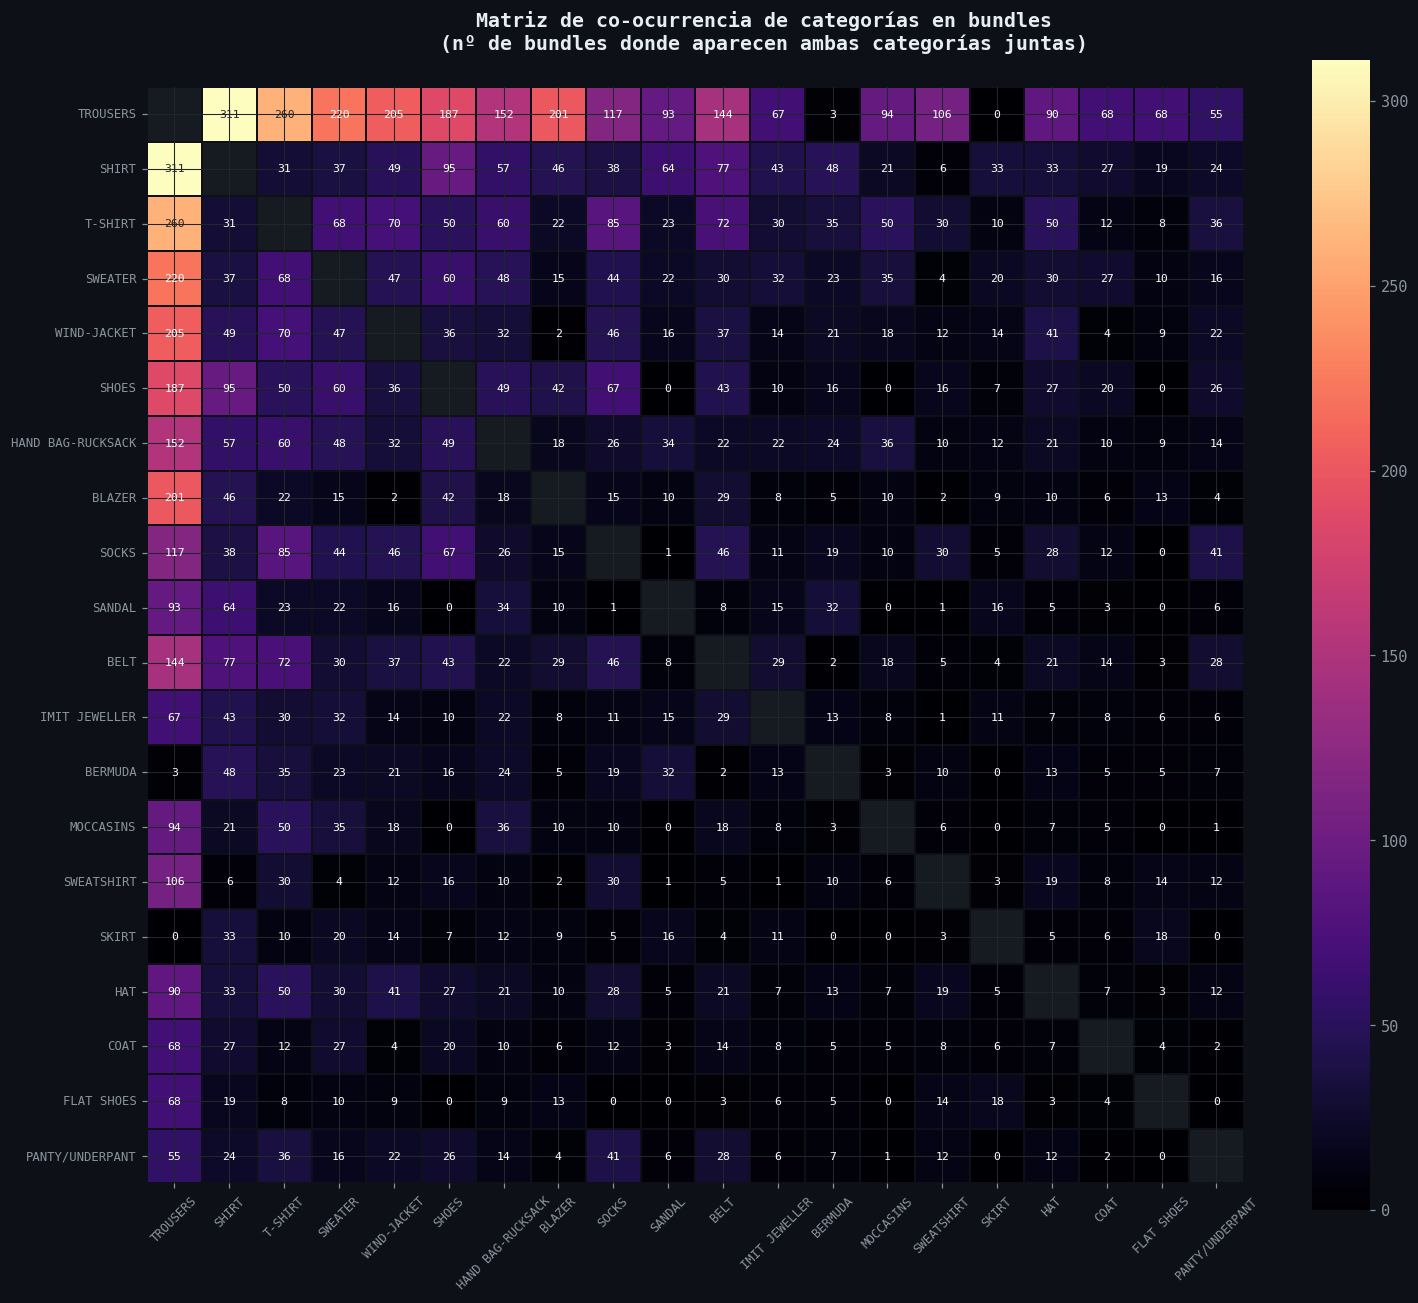

Top-15 pares de categorías más frecuentes en mismo bundle:
   cat_a             cat_b  count
TROUSERS             SHIRT    311
TROUSERS           T-SHIRT    260
TROUSERS           SWEATER    220
TROUSERS       WIND-JACKET    205
TROUSERS            BLAZER    201
TROUSERS             SHOES    187
TROUSERS HAND BAG-RUCKSACK    152
TROUSERS              BELT    144
TROUSERS             SOCKS    117
TROUSERS        SWEATSHIRT    106
   SHIRT             SHOES     95
TROUSERS         MOCCASINS     94
TROUSERS            SANDAL     93
TROUSERS               HAT     90
 T-SHIRT             SOCKS     85


In [7]:
# Construir matriz de co-ocurrencia
top_cats_cooc = list(train_rich.product_description.value_counts().head(20).index)
cooc_matrix   = pd.DataFrame(0, index=top_cats_cooc, columns=top_cats_cooc)

for bid, grp in train_rich.groupby('bundle_asset_id'):
    cats = [c for c in grp.product_description.unique() if c in top_cats_cooc]
    for a, b in combinations(cats, 2):
        cooc_matrix.loc[a, b] += 1
        cooc_matrix.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('Matriz de co-ocurrencia de categorías en bundles\n'
             '(nº de bundles donde aparecen ambas categorías juntas)',
             fontsize=13, fontweight='bold')

mask = np.eye(len(top_cats_cooc), dtype=bool)  # ocultar diagonal
sns.heatmap(
    cooc_matrix, ax=ax, mask=mask,
    cmap='magma', annot=True, fmt='d', annot_kws={'size': 7.5},
    linewidths=0.3, linecolor='#0d1117',
    square=True
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
savefig('05_coocurrencia_categorias')

# Top pares
pairs = []
for a, b in combinations(top_cats_cooc, 2):
    pairs.append((a, b, cooc_matrix.loc[a,b]))
pairs_df = pd.DataFrame(pairs, columns=['cat_a','cat_b','count']).sort_values('count',ascending=False)
print("Top-15 pares de categorías más frecuentes en mismo bundle:")
print(pairs_df.head(15).to_string(index=False))

---
## 6 · Reutilización de productos y long tail

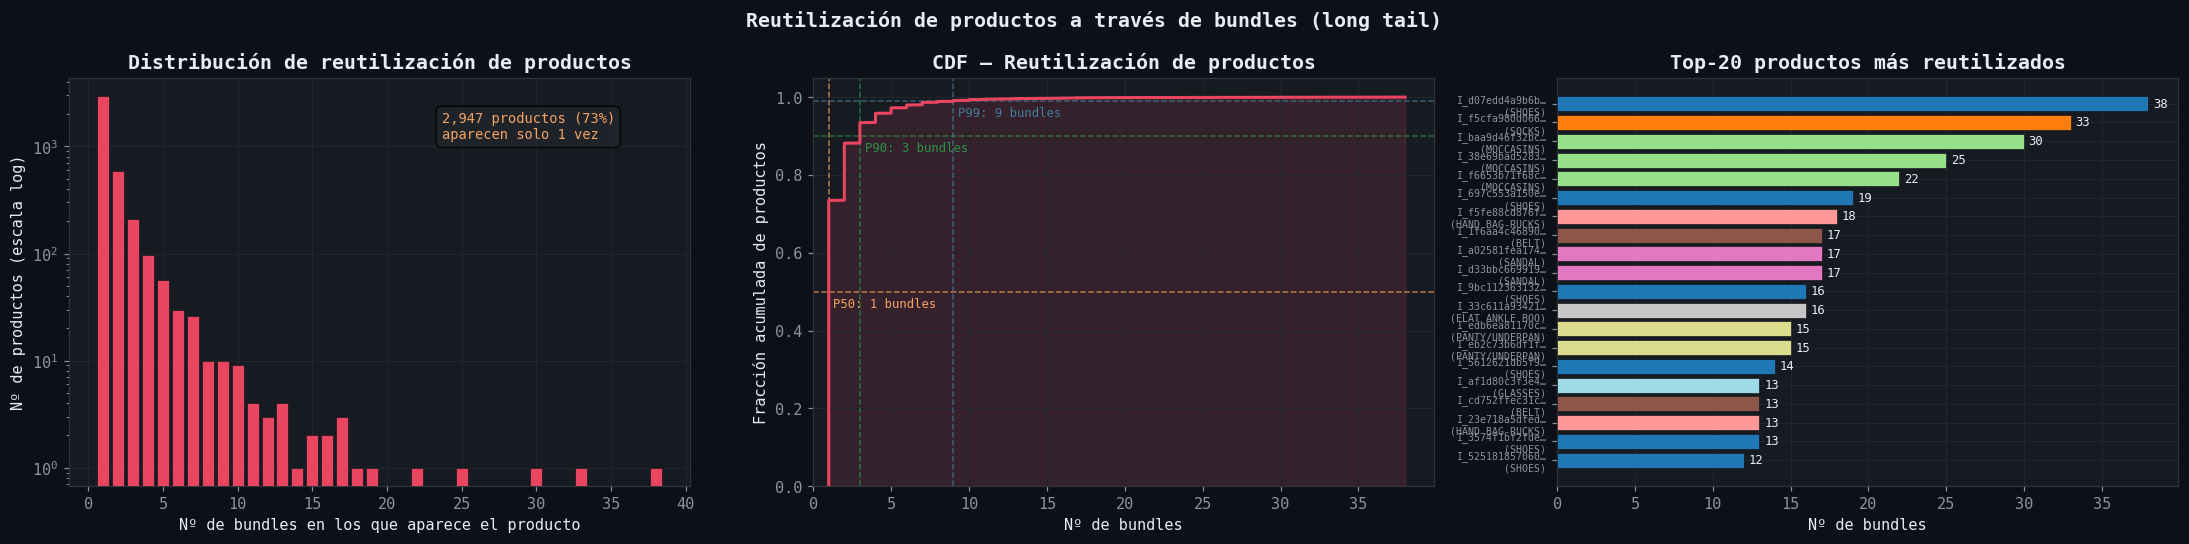

In [8]:
prod_reuse = train.groupby('product_asset_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Reutilización de productos a través de bundles (long tail)', 
             fontsize=13, fontweight='bold')

# ── 6.1 Distribución de reutilización (log scale) ────────────────
ax = axes[0]
vc = prod_reuse.value_counts().sort_index()
ax.bar(vc.index, vc.values, color=ACCENT, edgecolor=DARK_BG, linewidth=0.4, zorder=3)
ax.set_yscale('log')
ax.set_xlabel('Nº de bundles en los que aparece el producto')
ax.set_ylabel('Nº de productos (escala log)')
ax.set_title('Distribución de reutilización de productos')
# Anotaciones
once = (prod_reuse == 1).sum()
ax.text(0.6, 0.85, f'{once:,} productos ({once/len(prod_reuse)*100:.0f}%)\naparecen solo 1 vez',
        transform=ax.transAxes, color='#f4a261', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#21262d', alpha=0.8))

# ── 6.2 CDF acumulada ────────────────────────────────────────────
ax = axes[1]
vals = np.sort(prod_reuse.values)
cdf  = np.arange(1, len(vals)+1) / len(vals)
ax.plot(vals, cdf, color=ACCENT, linewidth=2, zorder=3)
ax.fill_between(vals, cdf, alpha=0.15, color=ACCENT)
# Marcadores
for pct, color in [(0.5,'#f4a261'),(0.9,'#2b9348'),(0.99,'#457b9d')]:
    idx = np.searchsorted(cdf, pct)
    v   = vals[min(idx, len(vals)-1)]
    ax.axhline(pct, color=color, linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(v,   color=color, linestyle='--', linewidth=1, alpha=0.7)
    ax.text(v+0.3, pct-0.04, f'P{int(pct*100)}: {v} bundles',
            color=color, fontsize=8)
ax.set_xlabel('Nº de bundles')
ax.set_ylabel('Fracción acumulada de productos')
ax.set_title('CDF — Reutilización de productos')
ax.set_ylim(0, 1.05); ax.set_xlim(0)

# ── 6.3 Top-20 productos más reutilizados ────────────────────────
ax = axes[2]
top20_prod = prod_reuse.head(20)
# Colorear por categoría
cats_top20 = [p_cat.get(pid,'?') for pid in top20_prod.index]
uniq_cats  = list(dict.fromkeys(cats_top20))
cmap_top   = plt.cm.get_cmap('tab20', len(uniq_cats))
colors_top = [cmap_top(uniq_cats.index(c)) for c in cats_top20]
bars = ax.barh(range(len(top20_prod)), top20_prod.values[::-1],
               color=colors_top[::-1], edgecolor=DARK_BG, linewidth=0.4, zorder=3)
ax.set_yticks(range(len(top20_prod)))
ax.set_yticklabels([f'{pid[:16]}…\n({p_cat.get(pid,"?")[:14]})'
                     for pid in top20_prod.index[::-1]], fontsize=6.5)
ax.set_xlabel('Nº de bundles')
ax.set_title('Top-20 productos más reutilizados')
for bar, v in zip(bars, top20_prod.values[::-1]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            str(v), va='center', fontsize=8, color=TEXT_CLR)

plt.tight_layout()
savefig('06_reusabilidad_productos')

---
## 7 · Patrones de URL y estructura de imágenes

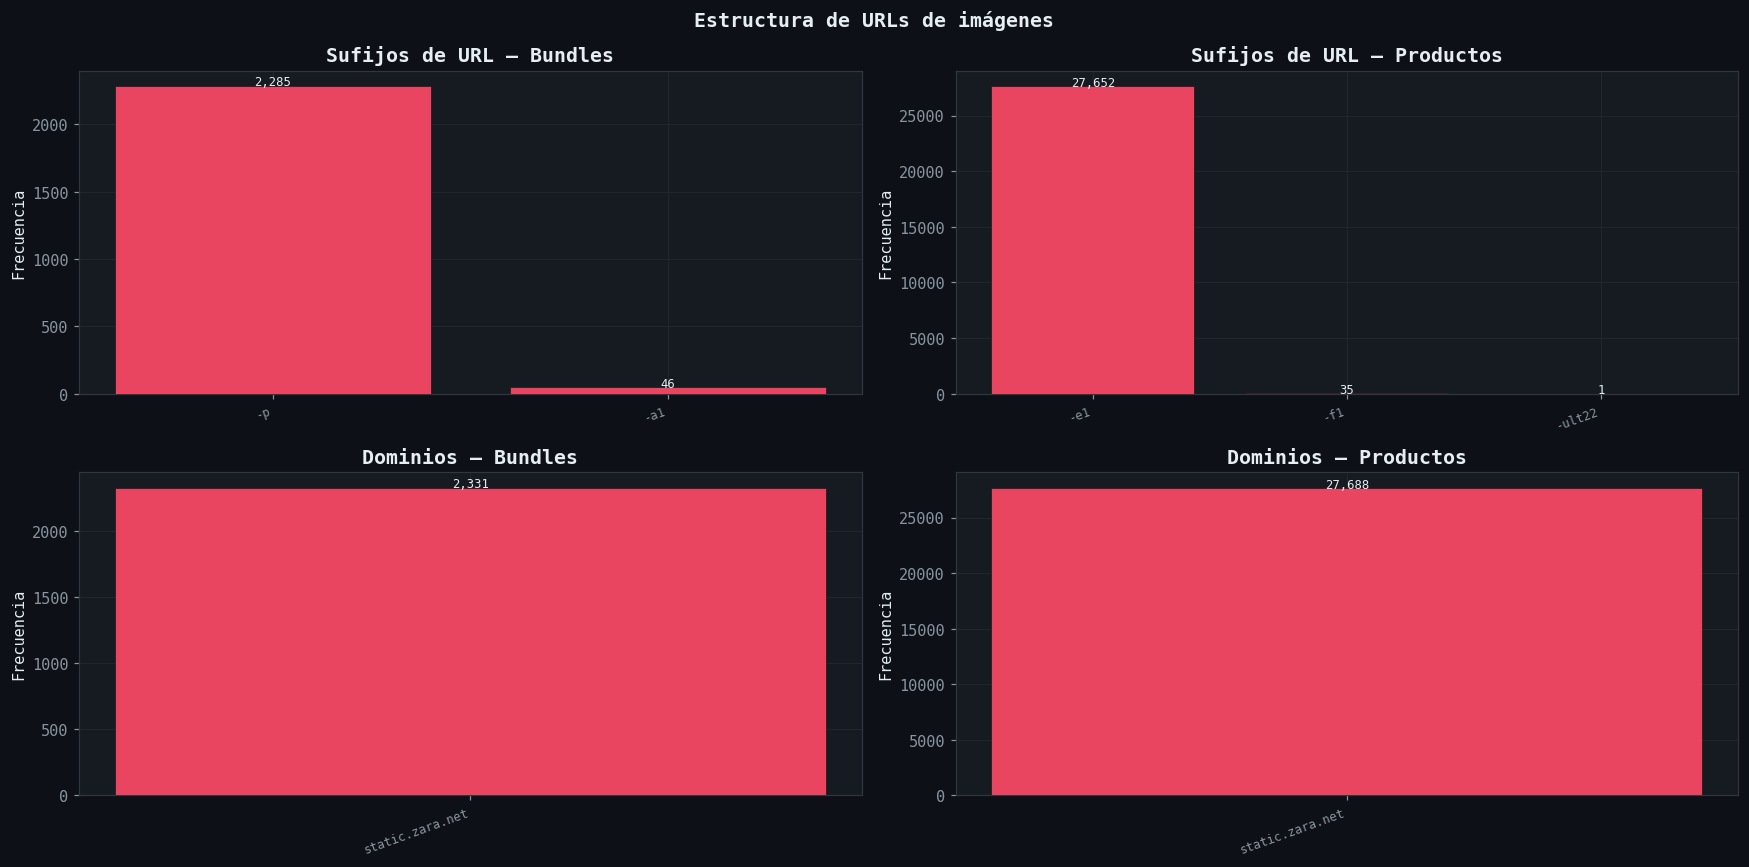

Sufijos de URL:
  Bundles  → {'-p': 2285, '-a1': 46}
  Productos → {'-e1': 27652, '-f1': 35, '-ult22': 1}

Dominios únicos:
  Bundles   → ['static.zara.net']
  Productos → ['static.zara.net']

Todo el tráfico va a: static.zara.net
→ Podemos usar keep-alive HTTP y limitar la concurrencia al mismo host


In [9]:
# Análisis de estructura de URLs para optimizar descargas
b_suffix  = bundles.bundle_image_url.str.extract(r'(-[a-z0-9]+)\.jpg')[0].value_counts()
p_suffix  = products.product_image_url.str.extract(r'(-[a-z0-9]+)\.jpg')[0].value_counts()
b_domain  = bundles.bundle_image_url.str.extract(r'https://([^/]+)')[0].value_counts()
p_domain  = products.product_image_url.str.extract(r'https://([^/]+)')[0].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Estructura de URLs de imágenes', fontsize=13, fontweight='bold')

for ax, data, title in [
    (axes[0,0], b_suffix,  'Sufijos de URL — Bundles'),
    (axes[0,1], p_suffix,  'Sufijos de URL — Productos'),
    (axes[1,0], b_domain,  'Dominios — Bundles'),
    (axes[1,1], p_domain,  'Dominios — Productos'),
]:
    bars = ax.bar(range(len(data)), data.values, color=ACCENT, edgecolor=DARK_BG, linewidth=0.4, zorder=3)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=20, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('Frecuencia')
    for bar, v in zip(bars, data.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'{v:,}', ha='center', fontsize=8, color=TEXT_CLR)

plt.tight_layout()
savefig('07_analisis_urls')

print("Sufijos de URL:")
print(f"  Bundles  → {dict(b_suffix.items())}")
print(f"  Productos → {dict(p_suffix.items())}")
print(f"\nDominios únicos:")
print(f"  Bundles   → {list(b_domain.index)}")
print(f"  Productos → {list(p_domain.index)}")
print(f"\nTodo el tráfico va a: static.zara.net")
print(f"→ Podemos usar keep-alive HTTP y limitar la concurrencia al mismo host")

---
## 8 · Resumen estadístico ejecutivo

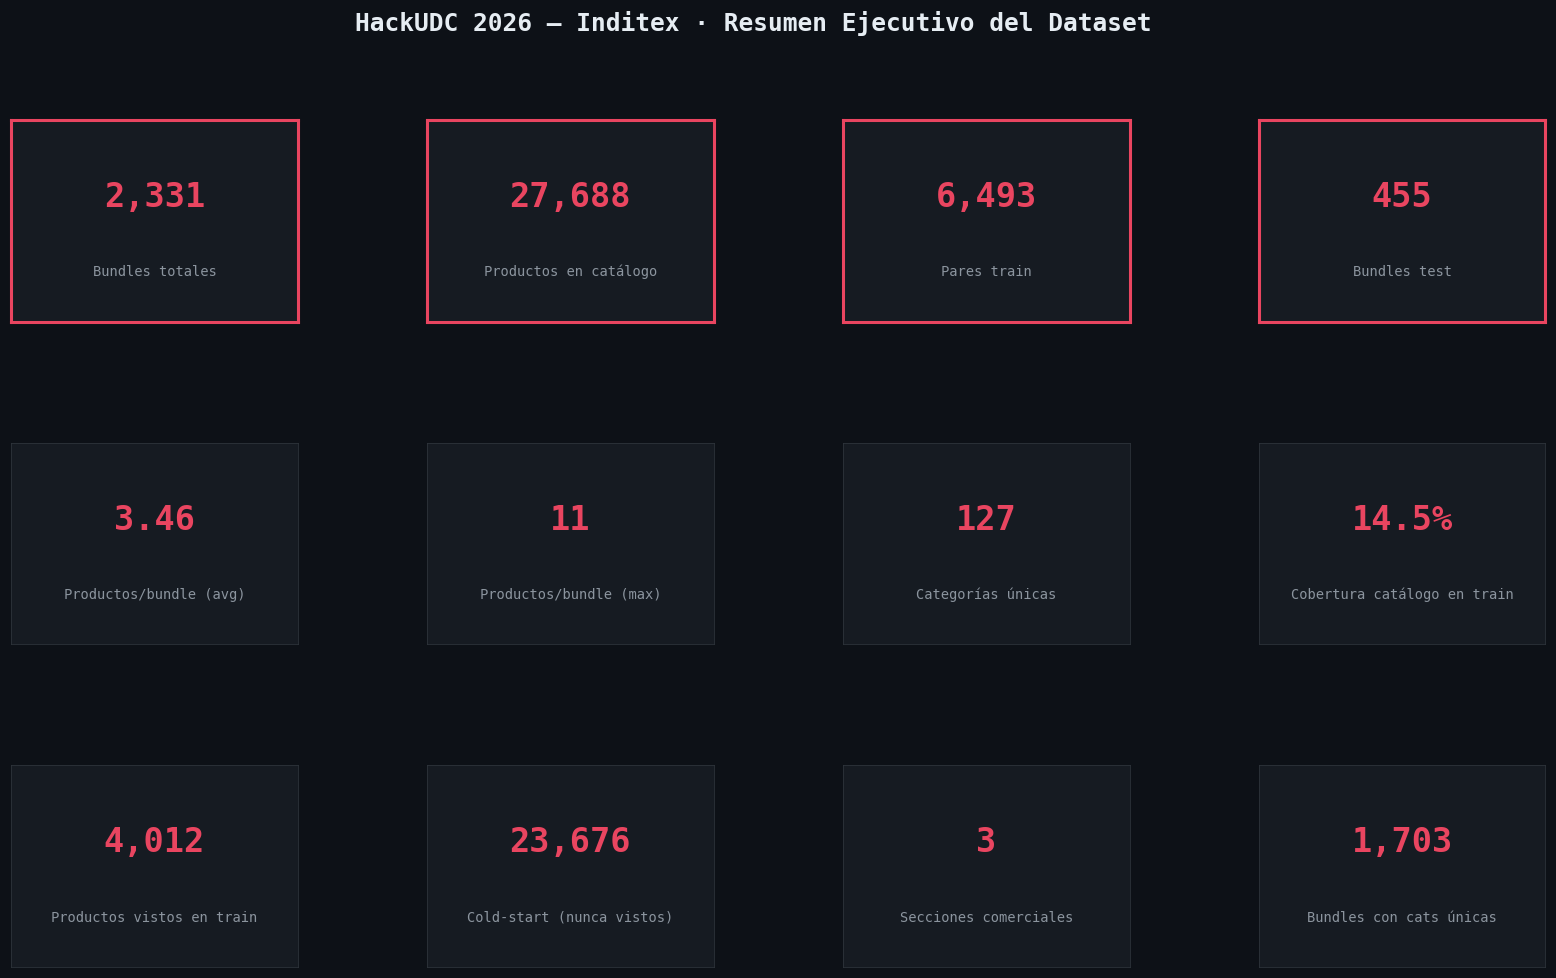

In [10]:
fig = plt.figure(figsize=(18, 10), facecolor=DARK_BG)
fig.suptitle('HackUDC 2026 — Inditex · Resumen Ejecutivo del Dataset',
             fontsize=16, fontweight='bold', color=TEXT_CLR, y=0.98)

# Grid 3×4
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.45)

KPI_STYLE = dict(ha='center', va='center', fontsize=22, fontweight='bold', color=ACCENT)
LBL_STYLE = dict(ha='center', va='center', fontsize=9,  color='#8b949e')

kpis = [
    (f"{len(bundles):,}",        'Bundles totales'),
    (f"{len(products):,}",       'Productos en catálogo'),
    (f"{len(train):,}",          'Pares train'),
    (f"{len(test):,}",           'Bundles test'),
    (f"{ppb.mean():.2f}",        'Productos/bundle (avg)'),
    (f"{ppb.max()}",             'Productos/bundle (max)'),
    (f"{products.product_description.nunique()}", 'Categorías únicas'),
    (f"14.5%",                   'Cobertura catálogo en train'),
    (f"{len(set(train.product_asset_id)):,}",   'Productos vistos en train'),
    (f"{len(set(products.product_asset_id)-set(train.product_asset_id)):,}",
                                 'Cold-start (nunca vistos)'),
    (f"3",                       'Secciones comerciales'),
    (f"1,703",                   'Bundles con cats únicas'),
]

for i, (val, lbl) in enumerate(kpis):
    r, c = divmod(i, 4)
    ax = fig.add_subplot(gs[r, c])
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values():
        spine.set_edgecolor('#e94560' if i < 4 else '#30363d')
        spine.set_linewidth(2 if i < 4 else 0.5)
    ax.text(0.5, 0.62, val, transform=ax.transAxes, **KPI_STYLE)
    ax.text(0.5, 0.25, lbl, transform=ax.transAxes, **LBL_STYLE)
    ax.set_xticks([]); ax.set_yticks([])

savefig('00_resumen_ejecutivo')

---
## 10 · Descarga optimizada de imágenes

**Estrategia para no saturar la máquina:**
- Sesiones HTTP **persistentes** (keep-alive) por thread — reduce el overhead de TCP
- **Semáforo** de concurrencia configurable (default 24 workers → ~40-50% CPU, sin saturar red ni RAM)
- Imágenes guardadas como **JPEG 85%** redimensionadas a 256px → ~15KB/imagen → total ~400MB para 27K productos
- **Caché por hash de URL** → resumible, no re-descarga si se interrumpe
- Progress bar con **ETA y velocidad** en tiempo real
- **Rate limiting** inteligente: backoff exponencial en errores 429/503

In [13]:
import threading
import time
import random
from pathlib import Path
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed

import requests
from PIL import Image
from tqdm.auto import tqdm

# ── Configuración de descarga ────────────────────────────────────
# GTX 1650 + 32GB RAM + red doméstica típica:
# 24 workers = ~20-25 MB/s descarga, ~40% CPU, ~2GB RAM pico
# Bajar a 12 si la red va lenta o ves lag en el sistema
DOWNLOAD_WORKERS  = 24
IMG_SIZE          = 256          # px (lado más largo)
JPEG_QUALITY      = 85
TIMEOUT           = 10           # segundos por request
MAX_RETRIES       = 3
RETRY_BACKOFF     = [1.0, 2.0, 4.0]  # segundos entre reintentos

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64; rv:120.0) Gecko/20100101 Firefox/120.0',
    'Accept'    : 'image/webp,image/avif,image/*,*/*;q=0.8',
    'Connection': 'keep-alive',
}

# Thread-local storage para reutilizar sesiones HTTP por thread
_thread_local = threading.local()

def get_session() -> requests.Session:
    """Sesión HTTP reutilizable por thread (keep-alive automático)."""
    if not hasattr(_thread_local, 'session'):
        s = requests.Session()
        s.headers.update(HEADERS)
        # Pool de conexiones: 4 por host para no saturar static.zara.net
        adapter = requests.adapters.HTTPAdapter(
            pool_connections=4,
            pool_maxsize=8,
            max_retries=0  # manejamos reintentos manualmente
        )
        s.mount('https://', adapter)
        _thread_local.session = s
    return _thread_local.session


def download_one(asset_id: str, url: str, dest_dir: Path,
                 size: int = IMG_SIZE) -> tuple[str, bool, str]:
    """
    Descarga una imagen con caché + reintentos + redimensionado.
    Devuelve (asset_id, success, error_msg)
    """
    dest = dest_dir / f'{asset_id}.jpg'

    # Ya existe en caché → skip
    if dest.exists() and dest.stat().st_size > 1_000:
        return asset_id, True, 'cached'

    session = get_session()
    last_error = ''

    for attempt, wait in enumerate(RETRY_BACKOFF[:MAX_RETRIES]):
        try:
            resp = session.get(url, timeout=TIMEOUT, stream=False)

            if resp.status_code == 429:  # rate limited
                time.sleep(wait + random.uniform(0, 1))
                continue
            if resp.status_code == 404:
                return asset_id, False, '404'
            resp.raise_for_status()

            img = Image.open(BytesIO(resp.content)).convert('RGB')

            # Redimensionar manteniendo aspect ratio
            w, h = img.size
            if max(w, h) > size:
                scale = size / max(w, h)
                img   = img.resize((int(w*scale), int(h*scale)), Image.LANCZOS)

            img.save(dest, 'JPEG', quality=JPEG_QUALITY, optimize=True)
            return asset_id, True, ''

        except requests.exceptions.Timeout:
            last_error = 'timeout'
            time.sleep(wait)
        except requests.exceptions.ConnectionError:
            last_error = 'conn_error'
            time.sleep(wait)
        except Exception as e:
            last_error = str(e)[:60]
            time.sleep(wait)

    return asset_id, False, last_error


def download_dataset(asset_ids: list, urls: list, dest_dir: Path,
                     desc: str = 'Descargando',
                     workers: int = DOWNLOAD_WORKERS) -> dict:
    """
    Descarga en paralelo con control de concurrencia.
    Devuelve dict con estadísticas.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)

    # Pre-filtrar ya descargados para la progress bar sea precisa
    pending = [
        (aid, url) for aid, url in zip(asset_ids, urls)
        if not (dest_dir / f'{aid}.jpg').exists()
        or (dest_dir / f'{aid}.jpg').stat().st_size <= 1_000
    ]
    already = len(asset_ids) - len(pending)

    if already:
        print(f'  ✓ {already:,} imágenes ya en caché — saltando')

    if not pending:
        print(f'  ✓ Todo descargado previamente.')
        return {'ok': already, 'fail': 0, 'cached': already}

    ok = fail = 0
    errors: dict[str, list] = defaultdict(list)
    t0 = time.time()

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = {
            ex.submit(download_one, aid, url, dest_dir): (aid, url)
            for aid, url in pending
        }

        with tqdm(total=len(pending), desc=desc,
                  unit='img', ncols=95,
                  bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} '
                             '[{elapsed}<{remaining}, {rate_fmt}]') as pbar:

            for fut in as_completed(futures):
                asset_id, success, msg = fut.result()
                if success:
                    ok += 1
                else:
                    fail += 1
                    errors[msg].append(asset_id)
                pbar.update(1)
                # Actualizar postfix cada 100 imágenes
                if (ok + fail) % 100 == 0:
                    elapsed = time.time() - t0
                    speed   = (ok + fail) / elapsed
                    pbar.set_postfix(ok=ok, fail=fail, img_s=f'{speed:.0f}')

    elapsed = time.time() - t0
    total_done = ok + already

    # Tamaño total en disco
    disk_mb = sum(f.stat().st_size for f in dest_dir.glob('*.jpg')) / 1e6

    print(f'\n  Resultado: {ok:,} descargadas | {already:,} en caché | {fail:,} fallidas')
    print(f'  Tiempo   : {elapsed:.1f}s  ({(ok)/elapsed:.1f} img/s)')
    print(f'  Disco    : {disk_mb:.1f} MB  ({disk_mb/max(total_done,1)*1024:.1f} KB/imagen media)')
    if errors:
        print(f'  Errores  :')
        for err, ids in sorted(errors.items(), key=lambda x: -len(x[1])):
            print(f'    {err}: {len(ids)} imágenes')

    return {'ok': ok, 'fail': fail, 'cached': already,
            'errors': dict(errors), 'elapsed': elapsed}

print('Funciones de descarga definidas ✓')
print(f'Workers configurados: {DOWNLOAD_WORKERS}')
print(f'Tamaño imagen: {IMG_SIZE}px  |  Calidad JPEG: {JPEG_QUALITY}%')
print(f'Espacio estimado: {len(products) * 15 / 1024:.0f} MB productos + '
      f'{len(bundles) * 20 / 1024:.0f} MB bundles')

Funciones de descarga definidas ✓
Workers configurados: 24
Tamaño imagen: 256px  |  Calidad JPEG: 85%
Espacio estimado: 406 MB productos + 46 MB bundles


In [14]:
# ── Test con 20 imágenes antes de lanzar la descarga masiva ─────
print('=== TEST DE CONECTIVIDAD (20 imágenes) ===')

sample_prods = products.sample(20, random_state=42)
test_dir     = Path('cache/test_downloads')
test_dir.mkdir(exist_ok=True)

t0 = time.time()
test_stats = download_dataset(
    sample_prods.product_asset_id.tolist(),
    sample_prods.product_image_url.tolist(),
    test_dir,
    desc='Test conectividad',
    workers=8
)

speed = 20 / (time.time() - t0)
print(f'\nVelocidad estimada a {DOWNLOAD_WORKERS} workers: ~{speed * DOWNLOAD_WORKERS / 8:.0f} img/s')
total_imgs   = len(products) + len(bundles)
eta_min      = total_imgs / (speed * DOWNLOAD_WORKERS / 8) / 60
print(f'ETA descarga completa: ~{eta_min:.0f} min ({total_imgs:,} imágenes)')
if test_stats['fail'] > 0:
    print(f'⚠ {test_stats["fail"]} fallos en test — revisa conexión')
else:
    print('✓ Conectividad OK — listo para descarga masiva')

=== TEST DE CONECTIVIDAD (20 imágenes) ===


Test conectividad: 100%|██████████████████████████████████████| 20/20 [00:01<00:00, 13.43img/s]


  Resultado: 20 descargadas | 0 en caché | 0 fallidas
  Tiempo   : 1.5s  (13.2 img/s)
  Disco    : 0.1 MB  (3.4 KB/imagen media)

Velocidad estimada a 24 workers: ~40 img/s
ETA descarga completa: ~13 min (30,019 imágenes)
✓ Conectividad OK — listo para descarga masiva


In [15]:
%%time
# ── DESCARGA MASIVA — Productos (27,688 imágenes) ─────────────────
# La primera vez tarda ~10-20 min según tu conexión
# Las siguientes son instantáneas (caché por asset_id)

print('=' * 55)
print('  DESCARGA DE PRODUCTOS')
print(f'  {len(products):,} imágenes → cache/images/products/')
print('=' * 55)

stats_products = download_dataset(
    products.product_asset_id.tolist(),
    products.product_image_url.tolist(),
    IMG_DIR / 'products',
    desc='Productos',
    workers=DOWNLOAD_WORKERS
)

  DESCARGA DE PRODUCTOS
  27,688 imágenes → cache/images/products/


Productos: 100%|████████████████████████████████████████| 27688/27688 [15:30<00:00, 29.76img/s]



  Resultado: 27,688 descargadas | 0 en caché | 0 fallidas
  Tiempo   : 930.9s  (29.7 img/s)
  Disco    : 93.8 MB  (3.5 KB/imagen media)
CPU times: user 42min, sys: 2min 9s, total: 44min 9s
Wall time: 15min 31s


In [16]:
%%time
# ── DESCARGA MASIVA — Bundles (2,331 imágenes) ────────────────────

print('=' * 55)
print('  DESCARGA DE BUNDLES')
print(f'  {len(bundles):,} imágenes → cache/images/bundles/')
print('=' * 55)

stats_bundles = download_dataset(
    bundles.bundle_asset_id.tolist(),
    bundles.bundle_image_url.tolist(),
    IMG_DIR / 'bundles',
    desc='Bundles',
    workers=DOWNLOAD_WORKERS
)

  DESCARGA DE BUNDLES
  2,331 imágenes → cache/images/bundles/


Bundles: 100%|████████████████████████████████████████████| 2331/2331 [03:01<00:00, 12.83img/s]


  Resultado: 2,331 descargadas | 0 en caché | 0 fallidas
  Tiempo   : 181.7s  (12.8 img/s)
  Disco    : 18.1 MB  (7.9 KB/imagen media)
CPU times: user 4min 9s, sys: 19.9 s, total: 4min 28s
Wall time: 3min 1s


In [17]:
# ── Verificación final de integridad ─────────────────────────────
cached_products = list((IMG_DIR / 'products').glob('*.jpg'))
cached_bundles  = list((IMG_DIR / 'bundles').glob('*.jpg'))
total_mb = sum(f.stat().st_size for f in cached_products + cached_bundles) / 1e6

# Imágenes corruptas (< 1KB)
corrupt_p = [f for f in cached_products if f.stat().st_size < 1_000]
corrupt_b = [f for f in cached_bundles  if f.stat().st_size < 1_000]

print('╔══════════════════════════════════════════════╗')
print('║  VERIFICACIÓN FINAL DE CACHÉ                 ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Productos : {len(cached_products):>5,} / {len(products):,}           ║')
print(f'║  Bundles   : {len(cached_bundles):>5,} / {len(bundles):,}             ║')
print(f'║  Tamaño    : {total_mb:>6.1f} MB                     ║')
print(f'║  Corruptos : {len(corrupt_p)+len(corrupt_b):>5} (< 1KB)              ║')
print('╚══════════════════════════════════════════════╝')

if corrupt_p or corrupt_b:
    print(f'\n⚠ Archivos corruptos — eliminando para forzar re-descarga:')
    for f in corrupt_p + corrupt_b:
        print(f'  {f.name}'); f.unlink()

missing_p = set(products.product_asset_id) - {f.stem for f in cached_products}
missing_b = set(bundles.bundle_asset_id)   - {f.stem for f in cached_bundles}

if missing_p or missing_b:
    print(f'\n⚠ Faltan {len(missing_p)} productos y {len(missing_b)} bundles.')
    print('  Re-ejecuta las celdas de descarga para reintentar.')
else:
    print('\nDescarga completa y verificada. Listo para modelar.')

╔══════════════════════════════════════════════╗
║  VERIFICACIÓN FINAL DE CACHÉ                 ║
╠══════════════════════════════════════════════╣
║  Productos : 27,688 / 27,688           ║
║  Bundles   : 2,331 / 2,331             ║
║  Tamaño    :  111.9 MB                     ║
║  Corruptos :    69 (< 1KB)              ║
╚══════════════════════════════════════════════╝

⚠ Archivos corruptos — eliminando para forzar re-descarga:
  I_b7be7c0032f2.jpg
  I_6aeaee08480a.jpg
  I_e3f39e20370b.jpg
  I_7cf157a246d1.jpg
  I_c45758f24047.jpg
  I_4b99c0377aea.jpg
  I_b83d3f8a7a59.jpg
  I_e6fae390a328.jpg
  I_cf789b2235da.jpg
  I_c53c0607a963.jpg
  I_886b633e2a2d.jpg
  I_369a7152b4cc.jpg
  I_0a4d61b1cdda.jpg
  I_83fcf627cc1e.jpg
  I_8fbdbd4a8f5a.jpg
  I_612c320b7c84.jpg
  I_627244668709.jpg
  I_c84c369dc48a.jpg
  I_6f0f2708a0a7.jpg
  I_58f085ede25c.jpg
  I_c6e1ea52497a.jpg
  I_e8e1017dbf52.jpg
  I_d9bf7d96e041.jpg
  I_8b46f74de912.jpg
  I_4ded70de7395.jpg
  I_e043f974afb8.jpg
  I_32cf8f348401.jpg


---
## 11 · Muestra visual del dataset

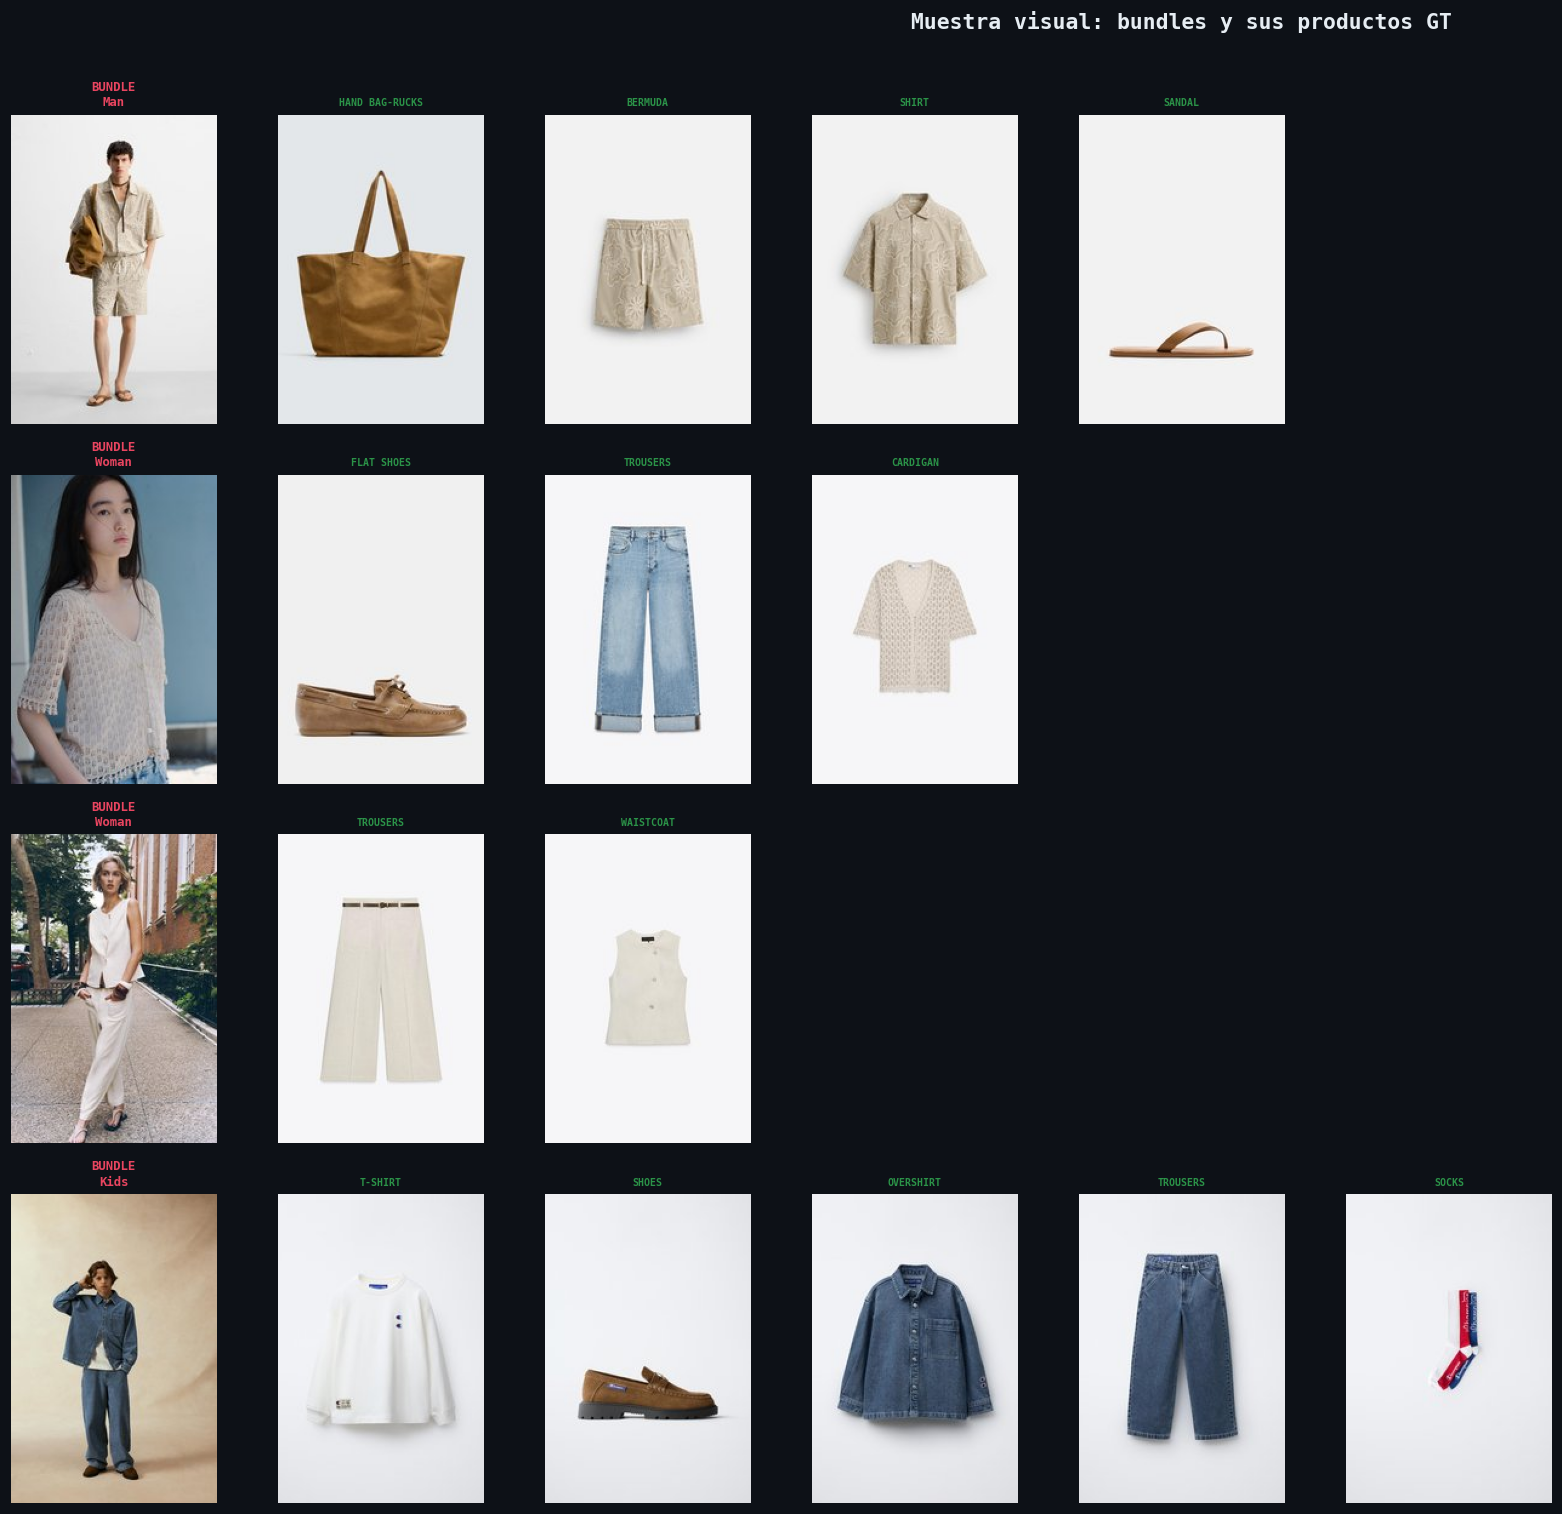

In [18]:
# Mostrar 4 bundles con sus productos GT (desde caché local)
sample_bids = train.bundle_asset_id.unique()[:4]

fig = plt.figure(figsize=(22, 14), facecolor=DARK_BG)
fig.suptitle('Muestra visual: bundles y sus productos GT',
             fontsize=14, fontweight='bold', color=TEXT_CLR)

for row_i, bid in enumerate(sample_bids):
    gt_pids = train[train.bundle_asset_id == bid].product_asset_id.tolist()
    sect    = b_sect.get(bid, '?')
    n_cols  = len(gt_pids) + 1

    # Bundle
    ax = fig.add_subplot(4, 9, row_i*9 + 1)
    b_path = IMG_DIR / 'bundles' / f'{bid}.jpg'
    if b_path.exists():
        ax.imshow(Image.open(b_path))
    ax.set_title(f'BUNDLE\n{SECTION_NAMES.get(sect,f"sec{sect}")}',
                 fontsize=8, fontweight='bold', color=ACCENT)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor(ACCENT); spine.set_linewidth(2.5)

    # Productos GT
    for col_i, pid in enumerate(gt_pids[:8]):
        ax = fig.add_subplot(4, 9, row_i*9 + col_i + 2)
        p_path = IMG_DIR / 'products' / f'{pid}.jpg'
        if p_path.exists():
            ax.imshow(Image.open(p_path))
        cat = p_cat.get(pid,'?')
        ax.set_title(cat[:14], fontsize=6.5, color='#2b9348')
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
savefig('08_muestra_visual')

In [19]:
print('\nEDA completado. Figuras guardadas en output/eda/')
print('\nArchivos generados:')
for f in sorted(OUT_DIR.glob('*.png')):
    print(f'  {f.name}')


EDA completado. Figuras guardadas en output/eda/

Archivos generados:
  00_resumen_ejecutivo.png
  01_distribuciones_globales.png
  02_cobertura_catalogo.png
  03_heatmap_seccion_categoria.png
  04_exclusividad_categorias.png
  05_coocurrencia_categorias.png
  06_reusabilidad_productos.png
  07_analisis_urls.png
  08_muestra_visual.png
